 # EmoLearn: All 4 Affective States
 Run the best model (Attn GRU + Focal + OS) on each state separately.

In [ ]:
import os, numpy as np, pandas as pd, matplotlib.pyplot as plt
from collections import Counter
import torch, torch.nn as nn, torch.nn.functional as F, torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

if torch.backends.mps.is_available(): device = torch.device("mps")
elif torch.cuda.is_available(): device = torch.device("cuda")
else: device = torch.device("cpu")
print(f"Device: {device}")

DAISEE_ROOT = "/Users/apple/Desktop/DAiSEE"
FEATURE_DIR = os.path.join(DAISEE_ROOT, "Features")
RESNET_DIM = 512; GEOM_DIM = 6; BATCH_SIZE = 32; NUM_EPOCHS = 30; LR = 1e-3

# Load cached features
train_app = np.load(os.path.join(FEATURE_DIR, "Train_appearance_seq.npy"))
train_geo = np.load(os.path.join(FEATURE_DIR, "Train_geometric_seq.npy"))
train_lbl = np.load(os.path.join(FEATURE_DIR, "Train_labels_seq.npy"))
val_app = np.load(os.path.join(FEATURE_DIR, "Validation_appearance_seq.npy"))
val_geo = np.load(os.path.join(FEATURE_DIR, "Validation_geometric_seq.npy"))
val_lbl = np.load(os.path.join(FEATURE_DIR, "Validation_labels_seq.npy"))
test_app = np.load(os.path.join(FEATURE_DIR, "Test_appearance_seq.npy"))
test_geo = np.load(os.path.join(FEATURE_DIR, "Test_geometric_seq.npy"))
test_lbl = np.load(os.path.join(FEATURE_DIR, "Test_labels_seq.npy"))

# Labels: col 0=Boredom, 1=Engagement, 2=Confusion, 3=Frustration
STATE_NAMES = ["Boredom", "Engagement", "Confusion", "Frustration"]
print(f"Features loaded. Shape: {train_app.shape}")

Device: mps
Features loaded. Shape: (4852, 10, 512)


In [ ]:
class SeqDataset(Dataset):
    def __init__(self, app, geo, labels, target_col, binary=True):
        self.app = torch.tensor(app, dtype=torch.float32)
        self.geo = torch.tensor(geo, dtype=torch.float32)
        raw = labels[:, target_col]
        self.labels = torch.tensor((raw >= 2).astype(np.int64) if binary else raw, dtype=torch.long)
    def __len__(self): return len(self.labels)
    def __getitem__(self, idx): return self.app[idx], self.geo[idx], self.labels[idx]

class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0):
        super().__init__()
        self.gamma = gamma
        self.alpha = alpha if isinstance(alpha, torch.Tensor) else (torch.tensor(alpha) if alpha is not None else None)
    def forward(self, inputs, targets):
        ce = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce)
        w = (1 - pt) ** self.gamma
        if self.alpha is not None: w = self.alpha.to(inputs.device)[targets] * w
        return (w * ce).mean()

class AttentionGRU(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.agru = nn.GRU(RESNET_DIM, 64, batch_first=True)
        self.ggru = nn.GRU(GEOM_DIM, 32, batch_first=True)
        self.attn_a = nn.Linear(64, 32); self.attn_g = nn.Linear(32, 32); self.attn_s = nn.Linear(32, 1)
        self.cls = nn.Sequential(nn.Dropout(0.3), nn.Linear(96, 64), nn.ReLU(), nn.Dropout(0.3), nn.Linear(64, num_classes))
    def forward(self, app, geo):
        _, ah = self.agru(app); _, gh = self.ggru(geo)
        ar, gr = ah[-1], gh[-1]
        st = torch.stack([torch.tanh(self.attn_a(ar)), torch.tanh(self.attn_g(gr))], 1)
        w = torch.softmax(self.attn_s(st).squeeze(-1), 1)
        return self.cls(torch.cat([ar * w[:, 0:1], gr * w[:, 1:2]], 1))

# Also test StatMLP
def compute_stat_features(seq):
    return np.concatenate([seq.mean(1), seq.std(1), seq.min(1), seq.max(1)], axis=1)

class StatMLP(nn.Module):
    def __init__(self, app_dim=RESNET_DIM*4, geo_dim=GEOM_DIM*4, num_classes=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(app_dim + geo_dim, 256), nn.ReLU(), nn.BatchNorm1d(256), nn.Dropout(0.3),
            nn.Linear(256, 64), nn.ReLU(), nn.Dropout(0.3), nn.Linear(64, num_classes))
    def forward(self, app, geo):
        return self.net(torch.cat([app, geo], dim=1))

class StatDataset(Dataset):
    def __init__(self, app_stat, geo_stat, labels, target_col, binary=True):
        self.app = torch.tensor(app_stat, dtype=torch.float32)
        self.geo = torch.tensor(geo_stat, dtype=torch.float32)
        raw = labels[:, target_col]
        self.labels = torch.tensor((raw >= 2).astype(np.int64) if binary else raw, dtype=torch.long)
    def __len__(self): return len(self.labels)
    def __getitem__(self, idx): return self.app[idx], self.geo[idx], self.labels[idx]

# Precompute stat features
train_app_stat = compute_stat_features(train_app)
train_geo_stat = compute_stat_features(train_geo)
val_app_stat = compute_stat_features(val_app)
val_geo_stat = compute_stat_features(val_geo)
test_app_stat = compute_stat_features(test_app)
test_geo_stat = compute_stat_features(test_geo)

In [ ]:
def train_and_eval(model, train_loader, val_loader, test_loader, criterion, binary=True):
    """Train model, return test metrics."""
    model = model.to(device)
    if hasattr(criterion, 'weight') and criterion.weight is not None:
        criterion.weight = criterion.weight.to(device)
    if hasattr(criterion, 'alpha') and criterion.alpha is not None:
        criterion.alpha = criterion.alpha.to(device)
    
    optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)
    best_f1, best_state = 0, None
    
    for epoch in range(NUM_EPOCHS):
        model.train()
        for a, g, l in train_loader:
            a, g, l = a.to(device), g.to(device), l.to(device)
            optimizer.zero_grad(); criterion(model(a, g), l).backward(); optimizer.step()
        
        model.eval()
        vp, vl = [], []
        with torch.no_grad():
            for a, g, l in val_loader:
                a, g = a.to(device), g.to(device)
                vp.extend(model(a, g).argmax(1).cpu().numpy()); vl.extend(l.numpy())
        vf1 = f1_score(vl, vp, average="macro", zero_division=0)
        scheduler.step(1 - vf1)
        if vf1 > best_f1:
            best_f1 = vf1; best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"    Epoch {epoch+1:3d}: Val F1 {vf1:.4f}")
    
    if best_state: model.load_state_dict(best_state); model.to(device)
    
    # Test
    model.eval()
    tp, tl = [], []
    with torch.no_grad():
        for a, g, l in test_loader:
            a, g = a.to(device), g.to(device)
            tp.extend(model(a, g).argmax(1).cpu().numpy()); tl.extend(l.numpy())
    tp, tl = np.array(tp), np.array(tl)
    tn = ["Low", "High"] if binary else [f"L{i}" for i in range(4)]
    
    return {
        "accuracy": accuracy_score(tl, tp),
        "f1_macro": f1_score(tl, tp, average="macro", zero_division=0),
        "predictions": tp, "labels": tl,
        "report": classification_report(tl, tp, target_names=tn, zero_division=0)
    }

 ## Run All 4 States × 2 Models (Binary Classification)

In [ ]:
all_results = {}

for col, state_name in enumerate(STATE_NAMES):
    print(f"\n{'='*70}")
    print(f"AFFECTIVE STATE: {state_name} (col={col})")
    print(f"{'='*70}")
    
    # Check class distribution
    binary_labels = (train_lbl[:, col] >= 2).astype(int)
    counts = Counter(binary_labels)
    print(f"  Binary distribution (Train): Low={counts[0]}, High={counts[1]}")
    
    # --- Model 1: Attn GRU + Focal + OS ---
    print(f"\n  --- Attn GRU + Focal + OS ---")
    tr_ds = SeqDataset(train_app, train_geo, train_lbl, col, binary=True)
    va_ds = SeqDataset(val_app, val_geo, val_lbl, col, binary=True)
    te_ds = SeqDataset(test_app, test_geo, test_lbl, col, binary=True)
    
    cw = torch.tensor([len(binary_labels) / (2 * max(counts[c], 1)) for c in [0, 1]], dtype=torch.float32)
    
    labels_arr = tr_ds.labels.numpy()
    w_per_sample = {c: len(labels_arr) / n for c, n in Counter(labels_arr).items()}
    sampler = WeightedRandomSampler([w_per_sample[int(l)] for l in labels_arr], len(labels_arr), replacement=True)
    
    tl = DataLoader(tr_ds, batch_size=BATCH_SIZE, sampler=sampler)
    vl = DataLoader(va_ds, batch_size=BATCH_SIZE, shuffle=False)
    tel = DataLoader(te_ds, batch_size=BATCH_SIZE, shuffle=False)
    
    model = AttentionGRU(num_classes=2)
    cr = FocalLoss(alpha=cw, gamma=2.0)
    r = train_and_eval(model, tl, vl, tel, cr, binary=True)
    all_results[f"{state_name} - Attn GRU"] = r
    print(f"  Test Acc: {r['accuracy']:.4f} | F1: {r['f1_macro']:.4f}")
    
    # --- Model 2: Stat Fusion MLP + OS ---
    print(f"\n  --- Stat Fusion MLP + OS ---")
    tr_stat_ds = StatDataset(train_app_stat, train_geo_stat, train_lbl, col, binary=True)
    va_stat_ds = StatDataset(val_app_stat, val_geo_stat, val_lbl, col, binary=True)
    te_stat_ds = StatDataset(test_app_stat, test_geo_stat, test_lbl, col, binary=True)
    
    labels_arr2 = tr_stat_ds.labels.numpy()
    w2 = {c: len(labels_arr2) / n for c, n in Counter(labels_arr2).items()}
    sampler2 = WeightedRandomSampler([w2[int(l)] for l in labels_arr2], len(labels_arr2), replacement=True)
    
    tl2 = DataLoader(tr_stat_ds, batch_size=BATCH_SIZE, sampler=sampler2)
    vl2 = DataLoader(va_stat_ds, batch_size=BATCH_SIZE, shuffle=False)
    tel2 = DataLoader(te_stat_ds, batch_size=BATCH_SIZE, shuffle=False)
    
    model2 = StatMLP(num_classes=2)
    cr2 = nn.CrossEntropyLoss()  # CE + OS works better for stat models
    r2 = train_and_eval(model2, tl2, vl2, tel2, cr2, binary=True)
    all_results[f"{state_name} - Stat MLP"] = r2
    print(f"  Test Acc: {r2['accuracy']:.4f} | F1: {r2['f1_macro']:.4f}")


AFFECTIVE STATE: Boredom (col=0)
  Binary distribution (Train): Low=3661, High=1191

  --- Attn GRU + Focal + OS ---
    Epoch   1: Val F1 0.2981
    Epoch  10: Val F1 0.3882
    Epoch  20: Val F1 0.5241
    Epoch  30: Val F1 0.5657
  Test Acc: 0.4951 | F1: 0.4752

  --- Stat Fusion MLP + OS ---
    Epoch   1: Val F1 0.5314
    Epoch  10: Val F1 0.5850
    Epoch  20: Val F1 0.6081
    Epoch  30: Val F1 0.6063
  Test Acc: 0.5818 | F1: 0.4944

AFFECTIVE STATE: Engagement (col=1)
  Binary distribution (Train): Low=234, High=4618

  --- Attn GRU + Focal + OS ---
    Epoch   1: Val F1 0.1041
    Epoch  10: Val F1 0.3837
    Epoch  20: Val F1 0.4119
    Epoch  30: Val F1 0.4906
  Test Acc: 0.8724 | F1: 0.5619

  --- Stat Fusion MLP + OS ---
    Epoch   1: Val F1 0.4818
    Epoch  10: Val F1 0.5642
    Epoch  20: Val F1 0.5654
    Epoch  30: Val F1 0.5544
  Test Acc: 0.9042 | F1: 0.6284

AFFECTIVE STATE: Confusion (col=2)
  Binary distribution (Train): Low=4392, High=460

  --- Attn GRU + Fo

 ## Summary Table

In [ ]:
print("\n" + "=" * 80)
print("ALL AFFECTIVE STATES: BINARY CLASSIFICATION RESULTS")
print("=" * 80)
print(f"{'State':<15} {'Model':<20} {'Accuracy':>10} {'F1 Macro':>10}")
print("-" * 80)

for state in STATE_NAMES:
    for model_type in ["Attn GRU", "Stat MLP"]:
        key = f"{state} - {model_type}"
        if key in all_results:
            r = all_results[key]
            print(f"{state:<15} {model_type:<20} {r['accuracy']:>10.4f} {r['f1_macro']:>10.4f}")
    print()

# Best per state
print("\nBEST MODEL PER STATE:")
print("-" * 60)
for state in STATE_NAMES:
    keys = [k for k in all_results if state in k]
    if keys:
        best_key = max(keys, key=lambda k: all_results[k]["f1_macro"])
        r = all_results[best_key]
        model_name = best_key.split(" - ")[1]
        print(f"  {state:<15} {model_name:<20} Acc={r['accuracy']:.4f}  F1={r['f1_macro']:.4f}")


ALL AFFECTIVE STATES: BINARY CLASSIFICATION RESULTS
State           Model                  Accuracy   F1 Macro
--------------------------------------------------------------------------------
Boredom         Attn GRU                 0.4951     0.4752
Boredom         Stat MLP                 0.5818     0.4944

Engagement      Attn GRU                 0.8724     0.5619
Engagement      Stat MLP                 0.9042     0.6284

Confusion       Attn GRU                 0.8217     0.5509
Confusion       Stat MLP                 0.8431     0.5794

Frustration     Attn GRU                 0.8492     0.5254
Frustration     Stat MLP                 0.8700     0.5627


BEST MODEL PER STATE:
------------------------------------------------------------
  Boredom         Stat MLP             Acc=0.5818  F1=0.4944
  Engagement      Stat MLP             Acc=0.9042  F1=0.6284
  Confusion       Stat MLP             Acc=0.8431  F1=0.5794
  Frustration     Stat MLP             Acc=0.8700  F1=0.5627


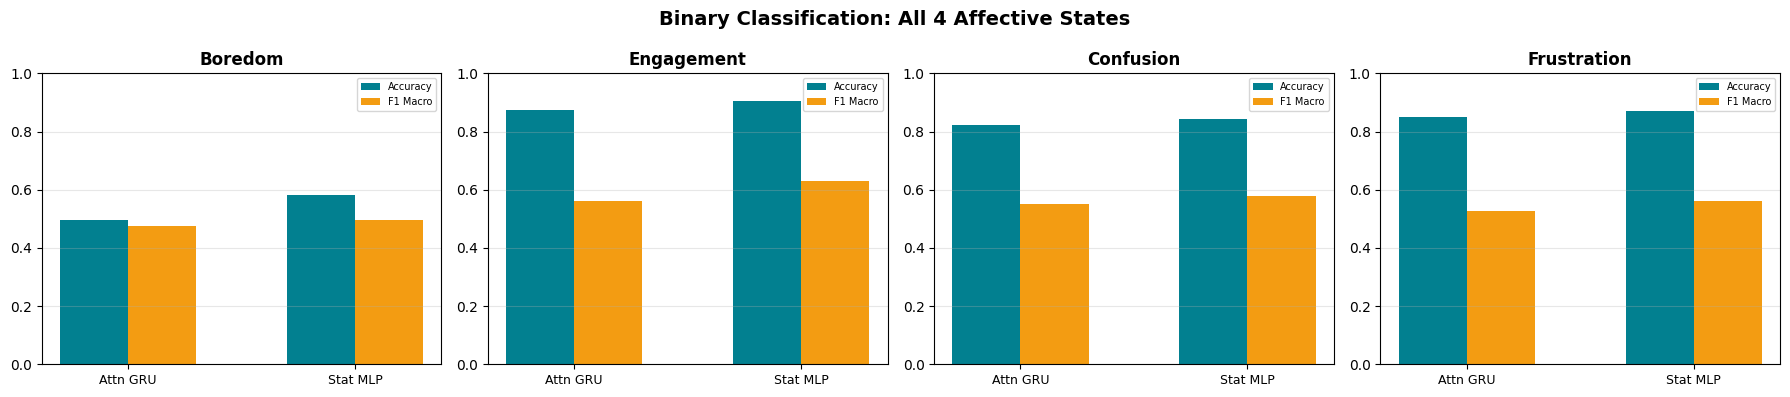

In [ ]:
# --- Visualization ---
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle("Binary Classification: All 4 Affective States", fontsize=14, fontweight="bold")

for idx, state in enumerate(STATE_NAMES):
    ax = axes[idx]
    models = ["Attn GRU", "Stat MLP"]
    accs = [all_results.get(f"{state} - {m}", {}).get("accuracy", 0) for m in models]
    f1s = [all_results.get(f"{state} - {m}", {}).get("f1_macro", 0) for m in models]
    
    x = np.arange(len(models))
    ax.bar(x - 0.15, accs, 0.3, label="Accuracy", color="#028090")
    ax.bar(x + 0.15, f1s, 0.3, label="F1 Macro", color="#F39C12")
    ax.set_xticks(x)
    ax.set_xticklabels(models, fontsize=9)
    ax.set_title(state, fontsize=12, fontweight="bold")
    ax.set_ylim(0, 1)
    ax.legend(fontsize=7)
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("all_states_results.png", dpi=150, bbox_inches="tight")
plt.show()

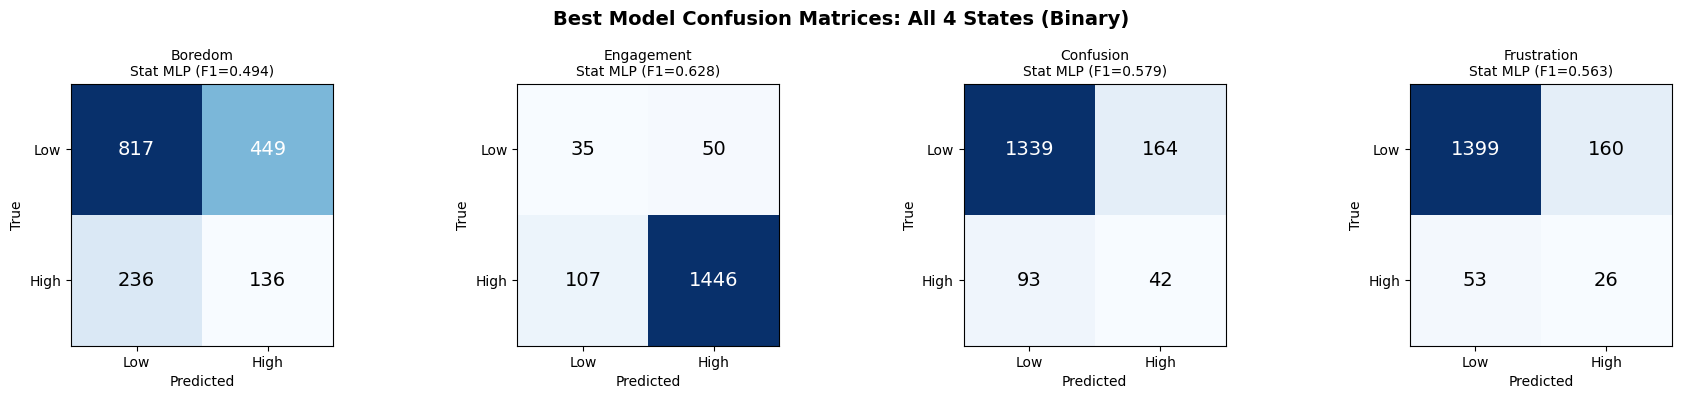

In [ ]:
# --- Confusion matrices for best model per state ---
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle("Best Model Confusion Matrices: All 4 States (Binary)", fontsize=14, fontweight="bold")

for idx, state in enumerate(STATE_NAMES):
    keys = [k for k in all_results if state in k]
    best_key = max(keys, key=lambda k: all_results[k]["f1_macro"])
    r = all_results[best_key]
    model_name = best_key.split(" - ")[1]
    
    cm = confusion_matrix(r["labels"], r["predictions"])
    ax = axes[idx]
    ax.imshow(cm, cmap="Blues")
    ax.set_title(f"{state}\n{model_name} (F1={r['f1_macro']:.3f})", fontsize=10)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(["Low", "High"]); ax.set_yticklabels(["Low", "High"])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                    color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=14)

plt.tight_layout()
plt.savefig("all_states_confusion.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# --- Classification reports ---
for state in STATE_NAMES:
    keys = [k for k in all_results if state in k]
    best_key = max(keys, key=lambda k: all_results[k]["f1_macro"])
    print(f"\n{'='*60}")
    print(f"{best_key}")
    print(f"{'='*60}")
    print(all_results[best_key]["report"])


Boredom - Stat MLP
              precision    recall  f1-score   support

         Low       0.78      0.65      0.70      1266
        High       0.23      0.37      0.28       372

    accuracy                           0.58      1638
   macro avg       0.50      0.51      0.49      1638
weighted avg       0.65      0.58      0.61      1638


Engagement - Stat MLP
              precision    recall  f1-score   support

         Low       0.25      0.41      0.31        85
        High       0.97      0.93      0.95      1553

    accuracy                           0.90      1638
   macro avg       0.61      0.67      0.63      1638
weighted avg       0.93      0.90      0.92      1638


Confusion - Stat MLP
              precision    recall  f1-score   support

         Low       0.94      0.89      0.91      1503
        High       0.20      0.31      0.25       135

    accuracy                           0.84      1638
   macro avg       0.57      0.60      0.58      1638
weighted 